In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_excel(r'C:\Users\legen\Downloads\2020-2026-NEPSE.xlsx')

In [3]:
df

,Date,Index Value
0,2020-01-01,1169.50
1,2020-01-02,1166.21
2,2020-01-05,1182.31
3,2020-01-06,1200.69
4,2020-01-07,1216.92
...,...,...
1458,2026-06-24,2660.02
1459,2026-06-25,2651.52
1460,2026-06-26,2649.51
1461,2026-06-29,2632.96


In [4]:
df.tail()

,Date,Index Value
1458,2026-06-24,2660.02
1459,2026-06-25,2651.52
1460,2026-06-26,2649.51
1461,2026-06-29,2632.96
1462,2026-06-30,2608.33


In [5]:
num_days = len(df)
tspan = np.arange(num_days)

In [6]:
num_days

1463

In [7]:
dates = pd.date_range(
    start='2020-01-01',
    periods=num_days,
    end='30-06-2026'
)

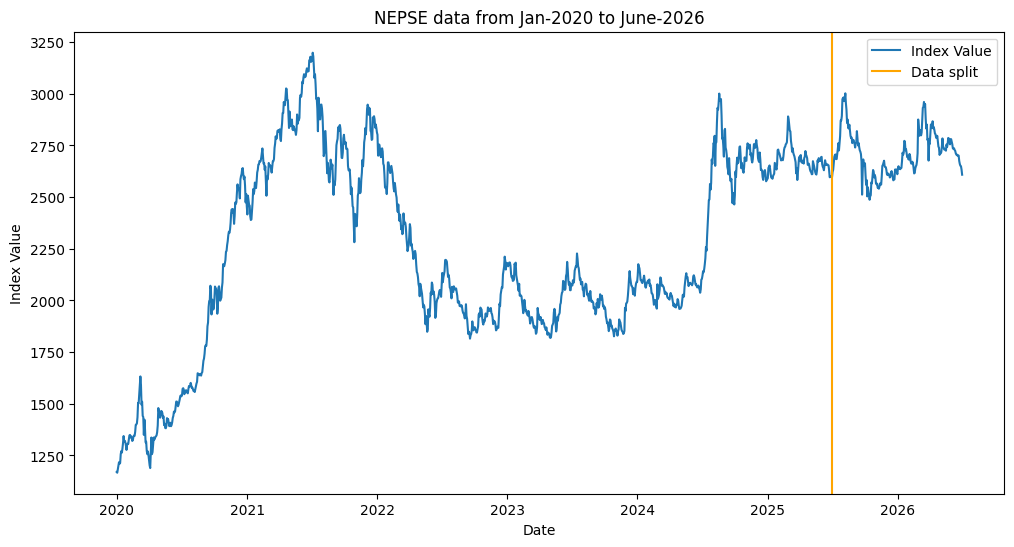

In [8]:
plt.figure(figsize=(12,6))
plt.plot(dates,df['Index Value'],label='Index Value')
plt.axvline(pd.Timestamp('2025-07'),color='orange',label='Data split')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.title('NEPSE data from Jan-2020 to June-2026')
plt.legend()
plt.show()

In [9]:
df['log_return']=np.log(df['Index Value']/df['Index Value'].shift(1))

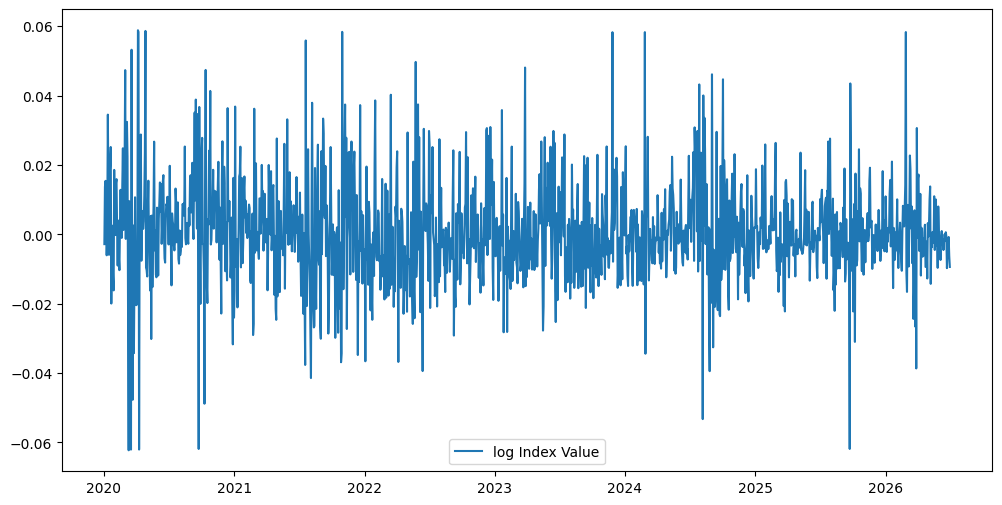

In [10]:
plt.figure(figsize=(12,6))
plt.plot(dates,df['log_return'],label='log Index Value')
plt.legend()
plt.show()

In [11]:
df['log_return'].describe()

count    1462.000000
mean        0.000549
std         0.014683
min        -0.062262
25%        -0.007566
50%        -0.000394
75%         0.007355
max         0.058847
Name: log_return, dtype: float64

In [12]:
# Split into train and validation
# -----------------------------
train = df[df['Date'] <= '2025-06-30']
test = df[df['Date'] > '2025-06-30']

print("Training observations :", len(train))
print("Validation observations :", len(test))


Training observations : 1240
Validation observations : 223


In [13]:
train.tail()

,Date,Index Value,log_return
1235,2025-06-24,2600.53,-0.000088
1236,2025-06-25,2600.20,-0.000127
1237,2025-06-26,2595.74,-0.001717
1238,2025-06-29,2622.28,0.010173
1239,2025-06-30,2631.48,0.003502


In [14]:
date1=pd.date_range(start='01-01-2020',
                    end='30-06-2025',
                    periods=len(train))

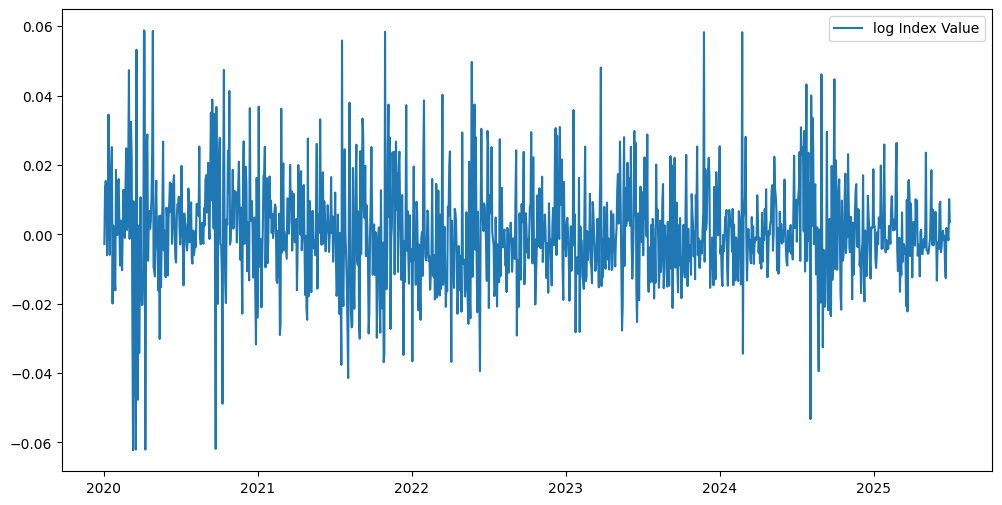

In [15]:
plt.figure(figsize=(12,6))
plt.plot(date1,train['log_return'],label='log Index Value')
plt.legend()
plt.show()

In [16]:
train.describe()

,Date,Index Value,log_return
count,1240,1240.000000,1239.000000
mean,2022-10-28 11:13:32.903225856,2230.607621,0.000655
min,2020-01-01 00:00:00,1166.210000,-0.062262
25%,2021-07-06 18:00:00,1939.397500,-0.007803
50%,2022-10-14 12:00:00,2112.380000,-0.000302
75%,2024-02-25 06:00:00,2651.805000,0.007658
max,2025-06-30 00:00:00,3198.600000,0.058847
std,NaN,457.718892,0.015148


In [17]:
train.tail()

,Date,Index Value,log_return
1235,2025-06-24,2600.53,-0.000088
1236,2025-06-25,2600.20,-0.000127
1237,2025-06-26,2595.74,-0.001717
1238,2025-06-29,2622.28,0.010173
1239,2025-06-30,2631.48,0.003502


In [18]:
# -----------------------------
# Estimate GBM parameters
# -----------------------------
dt = 1/252

sigma = train['log_return'].std()

mu = train['log_return'].mean()/dt + 0.5*sigma**2

print("Estimated Drift (mu):", mu)
print("Estimated Volatility (sigma):", sigma)


Estimated Drift (mu): 0.16505780638646164
Estimated Volatility (sigma): 0.015148031867127355


In [19]:
# Calculate log returns
train['log_return']=np.log(train['Index Value']/train['Index Value'].shift(1))
S0 = train['Index Value'].iloc[-1]   # latest price


C:\Users\legen\AppData\Local\Temp\ipykernel_132\4144258953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['log_return']=np.log(train['Index Value']/train['Index Value'].shift(1))


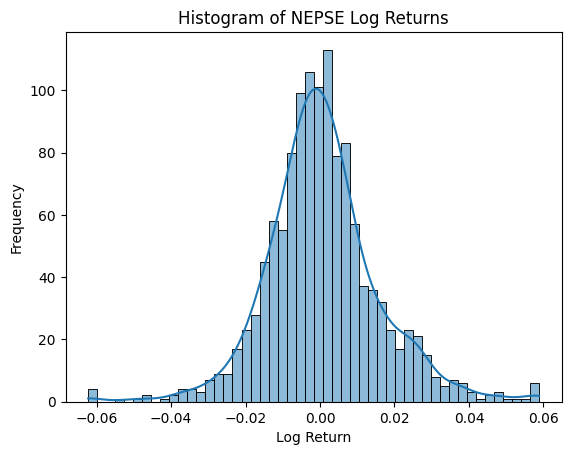

In [20]:
#checking distribution of Log return
#for histogram
sns.histplot(train['log_return'], bins=50,kde=True)
plt.title("Histogram of NEPSE Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()


In [25]:
sigma = train['log_return'].std() *(223)**0.5   # volatility
sigma
mu=r_m/dt + 0.5*(sigma**2)
mu

np.float64(0.17154664055545066)

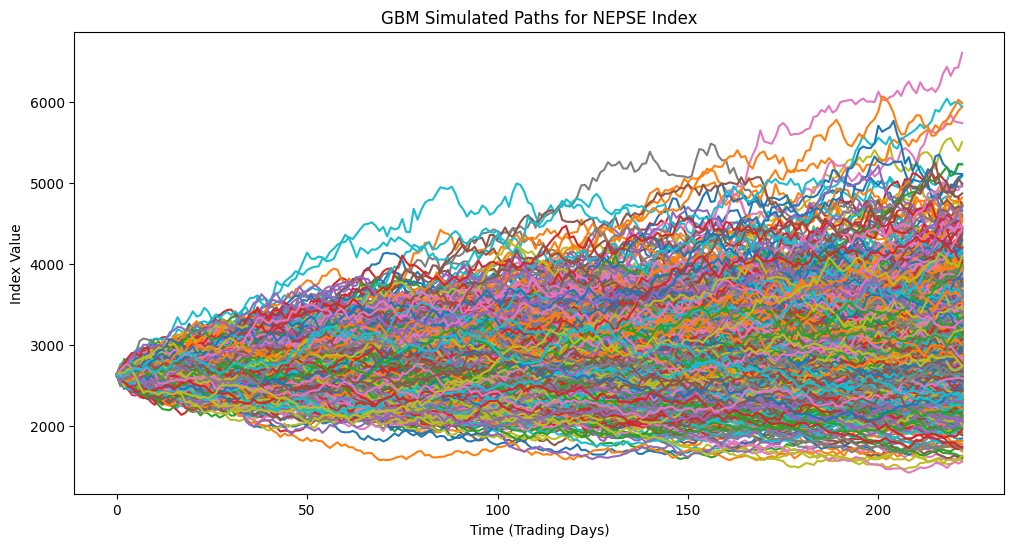

In [24]:

T = 223        # number of days to predict
dt = 1 / 223   # daily step
n_simulations = 1000

# Parameters
r_m = train['log_return'].mean()      # mean return
sigma = train['log_return'].std() *(223)**0.5   # volatility
mu=r_m/dt + 0.5*(sigma**2)

# Create simulation matrix
simulations = np.zeros((T, n_simulations))

# Generate GBM paths
for j in range(n_simulations):

    prices = [S0]

    for i in range(1, T):

        Z = np.random.normal(0, 1)

        next_price = prices[-1] * np.exp(
            (mu - 0.5 * sigma**2) * dt +
            sigma * np.sqrt(dt) * Z
        )

        prices.append(next_price)

    simulations[:, j] = prices

# Plot simulations
plt.figure(figsize=(12, 6))

for j in range(n_simulations):
    plt.plot(simulations[:, j])

plt.title("GBM Simulated Paths for NEPSE Index")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Index Value")
plt.show()

MAE : 214.11
RMSE : 237.54
MAPE : 7.94%


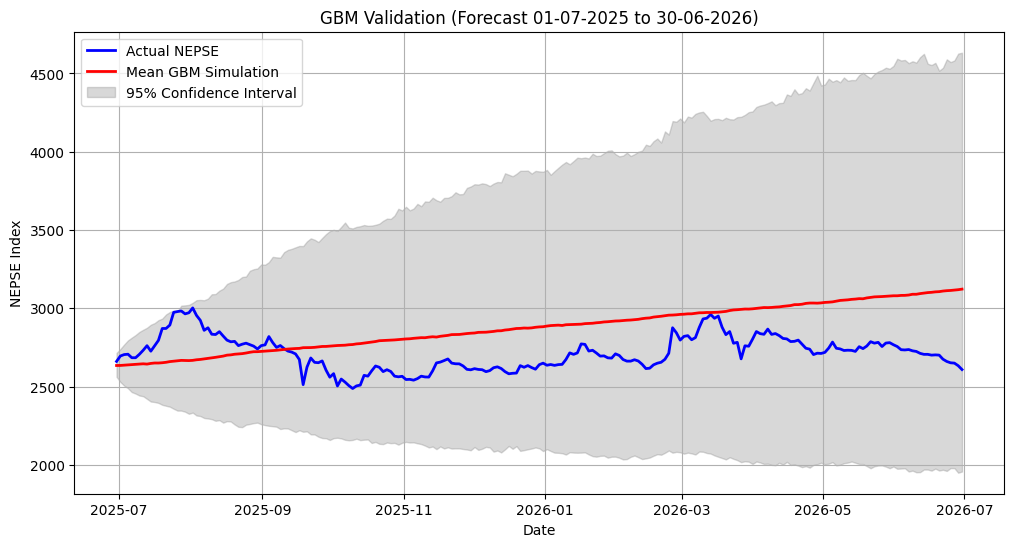

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

# -----------------------------
# Initial price
# -----------------------------
S0 = train['Index Value'].iloc[-1]

# Number of validation days
N = len(test)

# Number of simulations
n_sim = 1000

np.random.seed(42)

# -----------------------------
# Monte Carlo Simulation
# -----------------------------
paths = np.zeros((N+1, n_sim))
paths[0] = S0

for j in range(n_sim):
    for i in range(1, N+1):
        Z = np.random.normal()
        paths[i, j] = paths[i-1, j] * np.exp(
            (mu - 0.5*sigma**2)*dt +
            sigma*np.sqrt(dt)*Z
        )

# Remove initial value
paths = paths[1:]

# -----------------------------
# Mean prediction
# -----------------------------
mean_path = paths.mean(axis=1)

lower = np.percentile(paths, 2.5, axis=1)
upper = np.percentile(paths, 97.5, axis=1)

actual = test['Index Value'].values

# -----------------------------
# Validation Metrics
# -----------------------------
mae=mean_absolute_error(actual,mean_path)
rmse=mean_squared_error(actual,mean_path)**0.5
mape=mean_absolute_percentage_error(actual,mean_path)*100
print(f'MAE : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

date2 = pd.date_range(
    start='30-06-2025',
    periods=len(test),
    end='30-06-2026'
)
plt.plot(date2, actual,
         color='blue',
         linewidth=2,
         label='Actual NEPSE')

plt.plot(date2, mean_path,
         color='red',
         linewidth=2,
         label='Mean GBM Simulation')

plt.fill_between(date2,
                 lower,
                 upper,
                 color='gray',
                 alpha=0.3,
                 label='95% Confidence Interval')

plt.xlabel("Date")
plt.ylabel("NEPSE Index")
plt.title("GBM Validation (Forecast 01-07-2025 to 30-06-2026)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
quantiles = [0,0.05, 0.10, 0.15, 0.20, 0.25,
             0.30, 0.40, 0.50, 0.60, 0.70, 0.75,1]

for q in quantiles:
    prediction = np.quantile(paths, q, axis=1)
    score = mean_absolute_percentage_error(actual, prediction)
    print(f'{q} \t {score}')

0 	 0.34666105214308063
0.05 	 0.17960806393798343
0.1 	 0.13505221336677775
0.15 	 0.10235827589217067
0.2 	 0.07463806263770266
0.25 	 0.051766681258663655
0.3 	 0.036233682516079564
0.4 	 0.04130373231136643
0.5 	 0.0678396839902335
0.6 	 0.10131869217942188
0.7 	 0.1429655514890561
0.75 	 0.1673852925477442
1 	 0.700412001560191


In [ ]:
compare=pd.DataFrame({'Date':test['Date'],'Mean Simulated Value':mean_path, 'Actual Value':test['Index Value'].values})

MAE : 942.05
RMSE : 977.63
MAPE : 34.67%


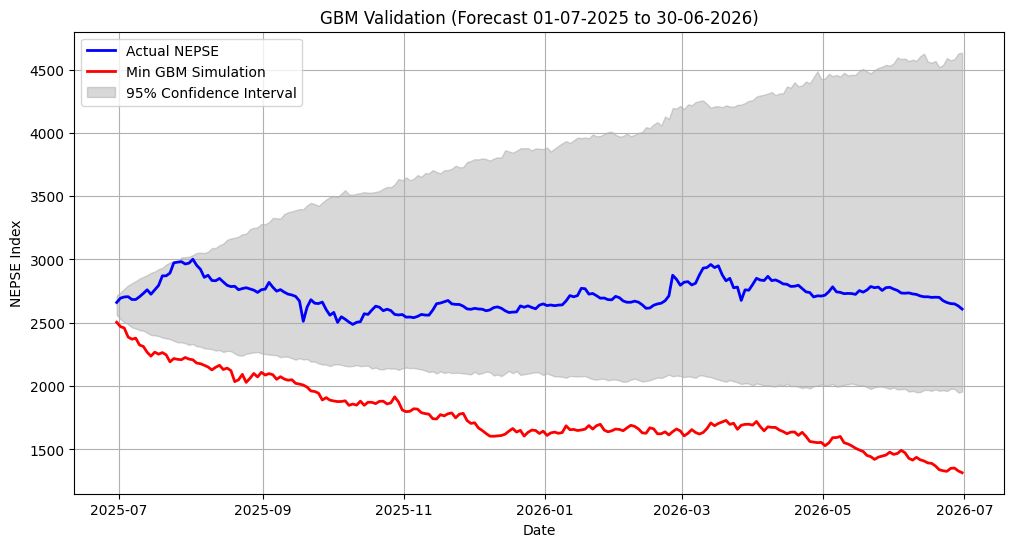

In [ ]:

# -----------------------------
# Initial price
# -----------------------------
S0 = train['Index Value'].iloc[-1]

# Number of validation days
N = len(test)

# Number of simulations
n_sim = 1000

np.random.seed(42)

# -----------------------------
# Monte Carlo Simulation
# -----------------------------
paths = np.zeros((N+1, n_sim))
paths[0] = S0

for j in range(n_sim):
    for i in range(1, N+1):
        Z = np.random.normal()
        paths[i, j] = paths[i-1, j] * np.exp(
            (mu - 0.5*sigma**2)*dt +
            sigma*np.sqrt(dt)*Z
        )

# Remove initial value
paths = paths[1:]

# -----------------------------
# Mean prediction
# -----------------------------
mean_path = np.min(paths,axis=1)

lower = np.percentile(paths, 2.5, axis=1)
upper = np.percentile(paths, 97.5, axis=1)

actual = test['Index Value'].values

# -----------------------------
# Validation Metrics
# -----------------------------
mae=mean_absolute_error(actual,mean_path)
rmse=mean_squared_error(actual,mean_path)**0.5
mape=mean_absolute_percentage_error(actual,mean_path)*100
print(f'MAE : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

date2 = pd.date_range(
    start='30-06-2025',
    periods=len(test),
    end='30-06-2026'
)
plt.plot(date2, actual,
         color='blue',
         linewidth=2,
         label='Actual NEPSE')

plt.plot(date2, mean_path,
         color='red',
         linewidth=2,
         label='Min GBM Simulation')

plt.fill_between(date2,
                 lower,
                 upper,
                 color='gray',
                 alpha=0.3,
                 label='95% Confidence Interval')

plt.xlabel("Date")
plt.ylabel("NEPSE Index")
plt.title("GBM Validation (Forecast 01-07-2025 to 30-06-2026)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(compare.to_latex)

<bound method NDFrame.to_latex of            Date  Mean Simulated Value  Actual Value
1240 2025-07-01           2634.291918       2660.39
1241 2025-07-02           2634.621689       2694.82
1242 2025-07-03           2636.357640       2703.96
1243 2025-07-06           2638.618585       2706.36
1244 2025-07-07           2639.504449       2684.01
...         ...                   ...           ...
1458 2026-06-24           3112.279943       2660.02
1459 2026-06-25           3113.683762       2651.52
1460 2026-06-26           3116.231746       2649.51
1461 2026-06-29           3118.538294       2632.96
1462 2026-06-30           3122.175224       2608.33

[223 rows x 3 columns]>


In [ ]:
print(train.to_latex(index=False))

\begin{tabular}{lrr}
\toprule
Date & Index Value & log_return \\
\midrule
2020-01-01 00:00:00 & 1169.500000 & NaN \\
2020-01-02 00:00:00 & 1166.210000 & -0.002817 \\
2020-01-05 00:00:00 & 1182.310000 & 0.013711 \\
2020-01-06 00:00:00 & 1200.690000 & 0.015426 \\
2020-01-07 00:00:00 & 1216.920000 & 0.013427 \\
2020-01-08 00:00:00 & 1209.600000 & -0.006033 \\
2020-01-09 00:00:00 & 1213.110000 & 0.002898 \\
2020-01-12 00:00:00 & 1255.720000 & 0.034522 \\
2020-01-13 00:00:00 & 1270.860000 & 0.011985 \\
2020-01-14 00:00:00 & 1263.380000 & -0.005903 \\
2020-01-15 00:00:00 & 1284.230000 & 0.016369 \\
2020-01-16 00:00:00 & 1310.230000 & 0.020043 \\
2020-01-19 00:00:00 & 1343.650000 & 0.025187 \\
2020-01-20 00:00:00 & 1317.110000 & -0.019950 \\
2020-01-21 00:00:00 & 1320.470000 & 0.002548 \\
2020-01-22 00:00:00 & 1313.420000 & -0.005353 \\
2020-01-23 00:00:00 & 1297.470000 & -0.012218 \\
2020-01-26 00:00:00 & 1276.680000 & -0.016153 \\
2020-01-27 00:00:00 & 1300.620000 & 0.018578 \\
2020-01-28 0

In [ ]:
test

,Date,Index Value,log_return
1240,2025-07-01,2660.39,0.010926
1241,2025-07-02,2694.82,0.012859
1242,2025-07-03,2703.96,0.003386
1243,2025-07-06,2706.36,0.000887
1244,2025-07-07,2684.01,-0.008293
...,...,...,...
1458,2026-06-24,2660.02,-0.005421
1459,2026-06-25,2651.52,-0.003201
1460,2026-06-26,2649.51,-0.000758
1461,2026-06-29,2632.96,-0.006266


In [ ]:

historical_returns = test['log_return'].values

# Log returns for each simulated path
simulated_returns = np.log(paths[1:] / paths[:-1])

# Convert all simulated returns into one 1D array
simulated_returns = simulated_returns.flatten()

In [ ]:
from scipy.stats import ks_2samp

ks_stat, p_value = ks_2samp(historical_returns, simulated_returns)

print("KS Statistic :", ks_stat)
print("P-value      :", p_value)

KS Statistic : 0.1582260534076677
P-value      : 2.4164663511631412e-05


In [ ]:
alpha = 0.05

if p_value > alpha:
    print("Fail to reject the null hypothesis.")
    print("The historical and simulated returns have similar distributions.")
else:
    print("Reject the null hypothesis.")
    print("The historical and simulated returns have significantly different distributions.")

Reject the null hypothesis.
The historical and simulated returns have significantly different distributions.


In [ ]:
from sklearn.linear_model import LinearRegression
df2=df.copy()

In [ ]:
df2['Date']=np.arange(len(df))

In [ ]:
X=df2[['Date']]
y=df2['Index Value']

In [ ]:
lr=LinearRegression().fit(X,y)

In [ ]:
y_pred = pd.Series(lr.predict(X), index=X.index)

Text(0, 0.5, 'Index Value')

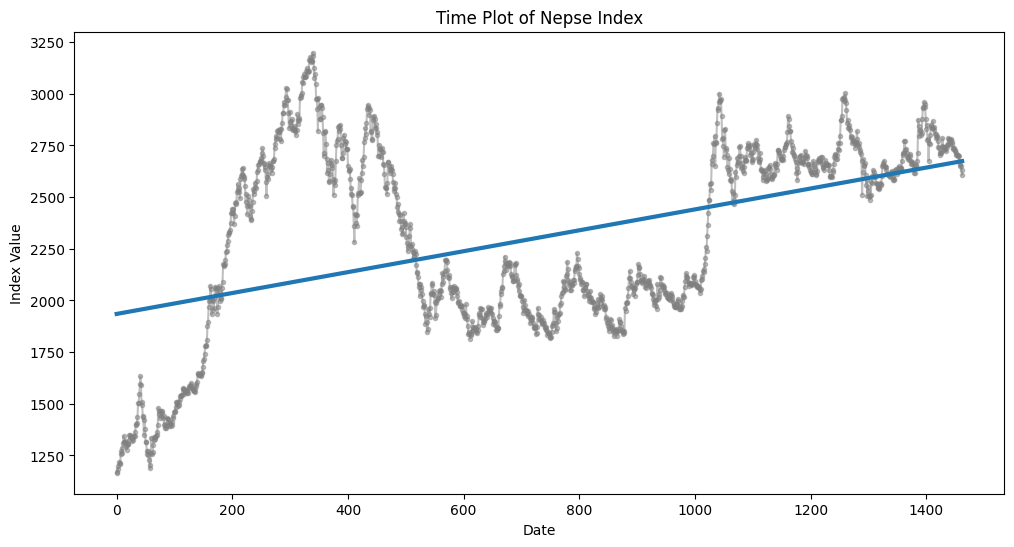

In [ ]:
plot_params = {
    'style': '.-',
    'color': 'gray',
    'figsize': (12, 6)
}

ax = y.plot(**plot_params, alpha=0.5)
ax = y_pred.plot(ax=ax, linewidth=3)

ax.set_title('Time Plot of Nepse Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred =pd.Series(model.predict(X_poly),index=X.index)

Text(0, 0.5, 'Index Value')

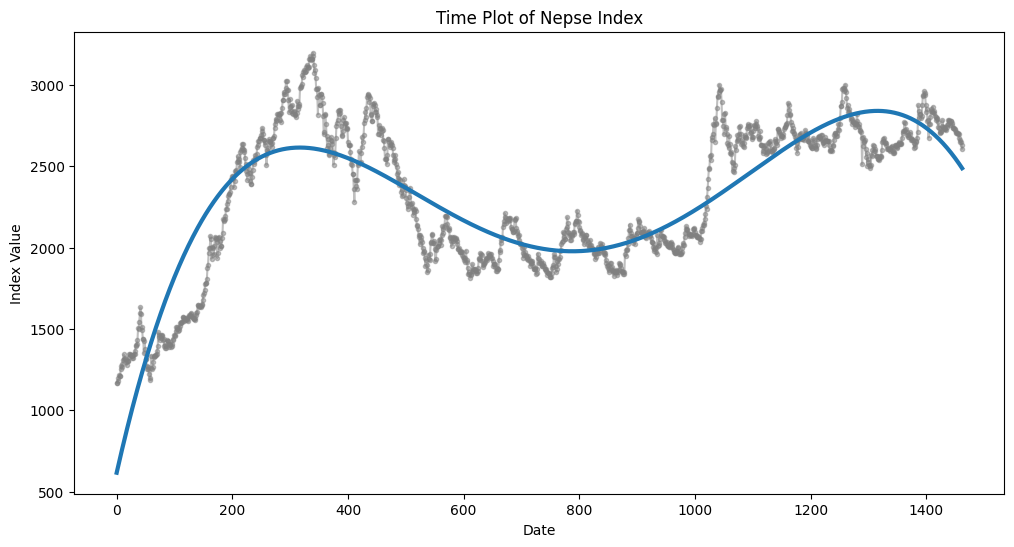

In [ ]:
ax = y.plot(**plot_params, alpha=0.5)
ax = y_pred.plot(ax=ax, linewidth=3)

ax.set_title('Time Plot of Nepse Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')

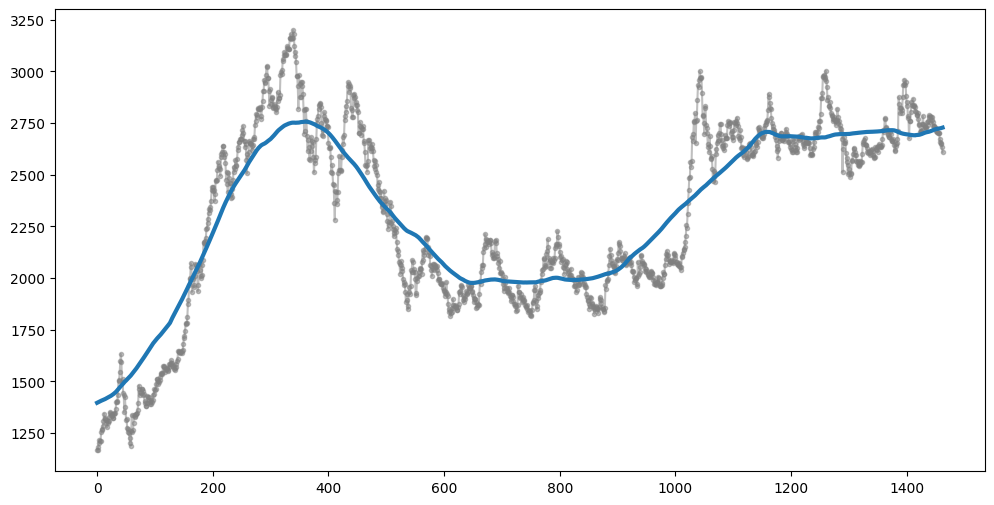

In [ ]:
# YOUR CODE HERE: Add methods to `food_sales` to compute a moving
# average with appropriate parameters for trend estimation.
eg = df2.loc[:, 'Index Value']
trend = eg.rolling(window=252,center=True,min_periods=0).mean()


# Make a plot
ax = eg.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

In [ ]:
from graphviz import Digraph

# =========================================================
# Create directed graph
# =========================================================
dot = Digraph(
    "Monte_Carlo_GBM",
    format="png"
)

# =========================================================
# Overall graph settings
# =========================================================
dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.05",
    margin="0",
    nodesep="0.25",
    ranksep="0.38",
    dpi="300",
    ratio="compress",
    size="7.5,11!"
)

# =========================================================
# Default node settings
# =========================================================
dot.attr(
    "node",
    shape="rectangle",
    style="rounded,filled",
    fontname="Times New Roman Bold",
    fontsize="18",
    margin="0.18,0.12",
    color="#1F2937",
    penwidth="3",
    fillcolor="#EAF2F8"
)

# =========================================================
# Default edge settings
# =========================================================
dot.attr(
    "edge",
    fontname="Times New Roman Bold",
    fontsize="15",
    color="#374151",
    penwidth="3",
    arrowsize="0.7"
)

# =========================================================
# Nodes
# =========================================================

# Start
dot.node(
    "start",
    "START",
    shape="oval",
    fontsize="19",
    fillcolor="#D5F5E3",
    color="#1E8449",
    penwidth="4"
)

# Historical data
dot.node(
    "data",
    "Read Historical NEPSE\nIndex Data",
    fillcolor="#D6EAF8"
)

# Log returns
dot.node(
    "returns",
    "Compute Daily\nLogarithmic Returns",
    fillcolor="#D6EAF8"
)

# Parameter estimation
dot.node(
    "parameters",
    "Estimate Parameters\nμ and σ",
    fillcolor="#D6EAF8"
)

# Initial value
dot.node(
    "initial",
    "Set Initial Index Value S₀\n= Last Training Value",
    fillcolor="#D6EAF8"
)

# Random variables
dot.node(
    "random",
    "Generate Independent\nStandard Normal Variables Zₜ",
    fillcolor="#FCF3CF"
)

# GBM update
dot.node(
    "gbm",
    "Compute GBM Update\n\n"
    "Sₜ₊Δₜ = Sₜ exp[(μ − ½σ²)Δt + σ√Δt Zₜ]",
    fontsize="18",
    fillcolor="#FDEBD0"
)

# Forecast horizon decision
dot.node(
    "horizon",
    "Forecast\nHorizon Reached?",
    shape="diamond",
    fontsize="17",
    fillcolor="#F9E79F",
    color="#B7950B",
    penwidth="4"
)

# Simulation decision
dot.node(
    "simulations",
    "1000 Simulations\nCompleted?",
    shape="diamond",
    fontsize="17",
    fillcolor="#F9E79F",
    color="#B7950B",
    penwidth="4"
)

# End
dot.node(
    "end",
    "END",
    shape="oval",
    fontsize="19",
    fillcolor="#F5B7B1",
    color="#922B21",
    penwidth="4"
)

# =========================================================
# Main vertical flow
# =========================================================

dot.edge("start", "data")
dot.edge("data", "returns")
dot.edge("returns", "parameters")
dot.edge("parameters", "initial")
dot.edge("initial", "random")
dot.edge("random", "gbm")
dot.edge("gbm", "horizon")

# =========================================================
# Forecast horizon decision
# =========================================================

dot.edge(
    "horizon",
    "random",
    label="NO",
    color="#C0392B",
    fontcolor="#C0392B",
    penwidth="3",
    constraint="false"
)

dot.edge(
    "horizon",
    "simulations",
    label="YES",
    color="#27AE60",
    fontcolor="#27AE60",
    penwidth="3"
)

# =========================================================
# Simulation decision
# =========================================================

dot.edge(
    "simulations",
    "initial",
    label="NO",
    color="#C0392B",
    fontcolor="#C0392B",
    penwidth="3",
    constraint="false"
)

dot.edge(
    "simulations",
    "end",
    label="YES",
    color="#27AE60",
    fontcolor="#27AE60",
    penwidth="3"
)

# =========================================================
# Generate diagram
# =========================================================

dot.render(
    "monte_carlo_gbm_algorithm",
    cleanup=True
)

print("Flowchart saved as monte_carlo_gbm_algorithm.png")


(process:21508): Pango-WARNING **: 07:03:48.530: couldn't load font "Times New Bold Not-Rotated 19", falling back to "Sans Bold Not-Rotated 19", expect ugly output.

(process:21508): Pango-WARNING **: 07:03:48.590: couldn't load font "Times New Bold Not-Rotated 18", falling back to "Sans Bold Not-Rotated 18", expect ugly output.

(process:21508): Pango-WARNING **: 07:03:48.600: couldn't load font "Times New Bold Not-Rotated 17", falling back to "Sans Bold Not-Rotated 17", expect ugly output.

(process:21508): Pango-WARNING **: 07:03:48.603: couldn't load font "Times New Bold Not-Rotated 15", falling back to "Sans Bold Not-Rotated 15", expect ugly output.


Flowchart saved as monte_carlo_gbm_algorithm.png
